# Early Stopping in Neural Network

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns

In [2]:
X , y = make_circles(n_samples=100, noise=0.1 , random_state = 1)

<Axes: >

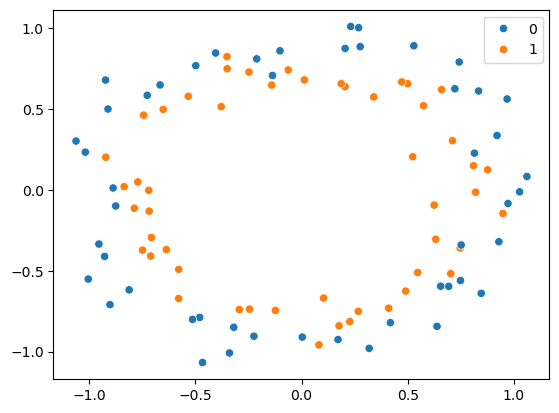

In [3]:
sns.scatterplot(x = X[:,0] , y = X[:,1] , hue = y)

In [4]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 2)

In [5]:
model = Sequential()
model.add(Dense(256, input_dim = 2 , activation='relu'))
model.add(Dense(1, activation='sigmoid'))

C:\Users\himan\anaconda3\envs\dl\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [7]:
history = model.fit(X_train , y_train , validation_data = (X_test , y_test ), epochs = 3500 , verbose = 0)

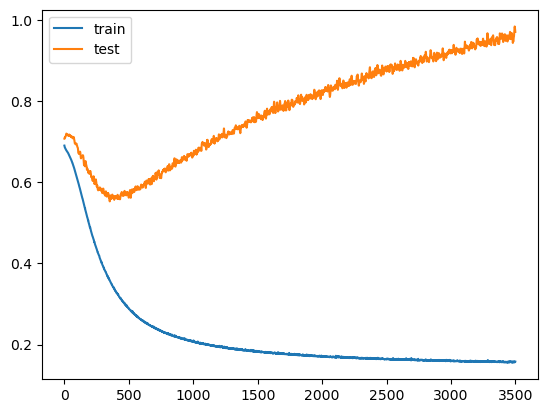

In [10]:
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [ ]:
# 3 EARLYSTOPPING AUTO DETECT THE OVERFITTING AND STOP THERE 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 753us/step


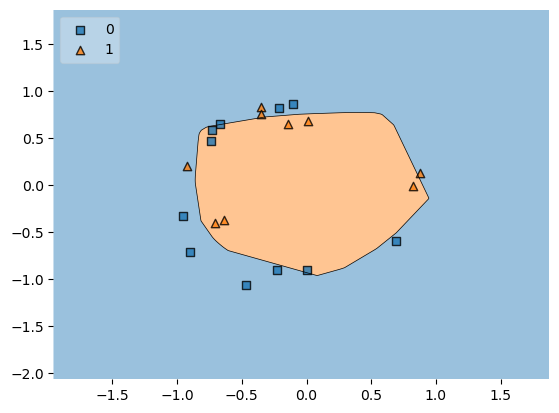

In [11]:
plot_decision_regions(X_test , y_test.ravel() , clf = model , legend = 2)
plt.show()

# Early Stopping

In [12]:
model = Sequential()
model.add(Dense(256 , input_dim = 2 , activation= 'relu'))
model.add(Dense(1 , activation='sigmoid'))

In [13]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [14]:
callback = EarlyStopping(
    monitor='val_loss',
    min_delta=0.00001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)

In [16]:
history = model.fit(X_train , y_train , validation_data = (X_test , y_test ), epochs = 3500 , callbacks=callback)

Epoch 1/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.5000 - loss: 0.6933 - val_accuracy: 0.4500 - val_loss: 0.6938
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5000 - loss: 0.6914 - val_accuracy: 0.5500 - val_loss: 0.6961
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5375 - loss: 0.6896 - val_accuracy: 0.4500 - val_loss: 0.6982
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5375 - loss: 0.6883 - val_accuracy: 0.4000 - val_loss: 0.7013
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5625 - loss: 0.6870 - val_accuracy: 0.4000 - val_loss: 0.7039
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5375 - loss: 0.6861 - val_accuracy: 0.4000 - val_loss: 0.7065
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5500 - loss: 0.6853 - val_accuracy: 0.4500 - val_loss: 0.7080
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5375 - loss: 0.6843 - val_accuracy: 0.4500 - v

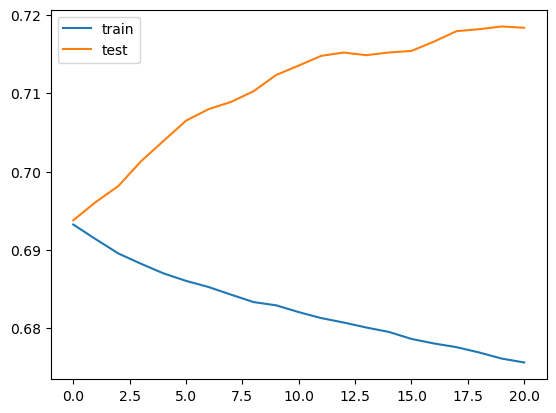

In [17]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 9s 902us/step


<Axes: >

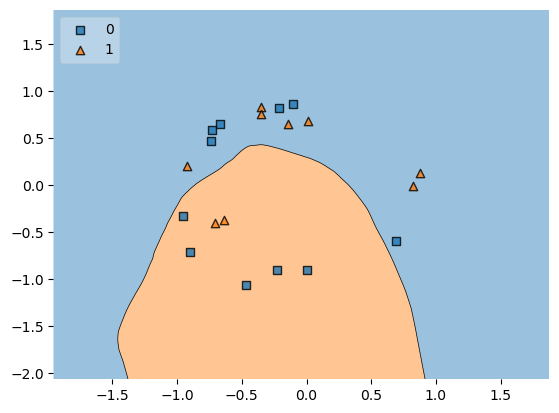

In [21]:
plot_decision_regions(X_test , y_test.ravel() , clf =model , legend = 2)